# 1. Vectors


Vector: [3. 2.]
Magnitude: 3.605551275463989


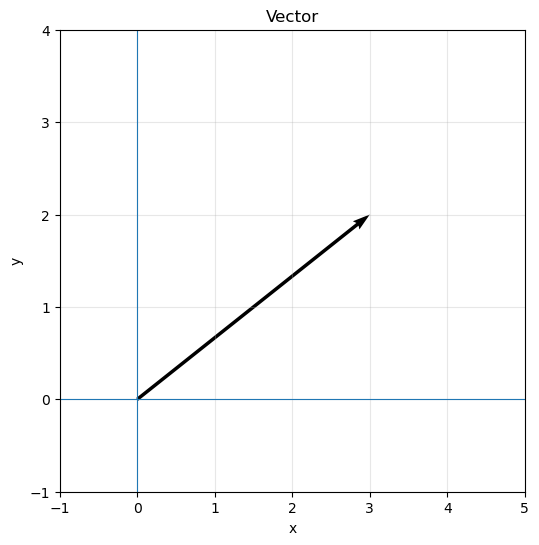

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

v = np.array([3.0, 2.0])
print("Vector:", v)
print("Magnitude:", np.linalg.norm(v))

plt.figure(figsize=(6, 6))
plt.quiver(0, 0, v[0], v[1], angles="xy", scale_units="xy", scale=1)
plt.xlim(-1, 5); plt.ylim(-1, 4)
plt.axhline(0, linewidth=0.8); plt.axvline(0, linewidth=0.8)
plt.grid(alpha=0.3); plt.xlabel("x"); plt.ylabel("y")
plt.title("Vector"); plt.show()


# 2. Matrices


In [ ]:
A = np.array([[2.0, 0.5], [0.2, 1.5]])
x = np.array([2.0, 1.0])

print("Matrix A:\n", A)
print("\nVector x:", x)
print("\nA @ x:", A @ x)


: 

In [ ]:
e1 = np.array([1.0, 0.0])
e2 = np.array([0.0, 1.0])
Ae1, Ae2 = A @ e1, A @ e2

plt.figure(figsize=(7, 6))
for vec, label in [(e1,"e1"), (e2,"e2"), (Ae1,"A e1"), (Ae2,"A e2")]:
    plt.quiver(0,0,vec[0],vec[1],angles="xy",scale_units="xy",scale=1,label=label)
plt.xlim(-1,4); plt.ylim(-1,4)
plt.axhline(0,linewidth=0.8); plt.axvline(0,linewidth=0.8)
plt.grid(alpha=0.3); plt.legend(); plt.title("Matrix Transformation")
plt.show()


# 3. Dot Product


In [ ]:
a = np.array([2.0, 3.0, 1.0])
b = np.array([0.5, 0.2, -0.4])

dot = np.dot(a, b)
print("a =", a)
print("b =", b)
print("Dot product =", dot)
print("Manual =", a[0]*b[0] + a[1]*b[1] + a[2]*b[2])


# 4. Eigenvalues and Eigenvectors


In [ ]:
A = np.array([[3.0, 1.0], [0.0, 2.0]])
eigenvalues, eigenvectors = np.linalg.eig(A)

print("Matrix A:\n", A)
print("\nEigenvalues:\n", eigenvalues)
print("\nEigenvectors (columns):\n", eigenvectors)

for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    print(f"\nEigenvalue {eigenvalues[i]:.4f}")
    print("A @ v      =", A @ v)
    print("lambda * v =", eigenvalues[i] * v)


In [ ]:
plt.figure(figsize=(7,6))
for i in range(len(eigenvalues)):
    v = eigenvectors[:,i]
    Av = A @ v
    plt.quiver(0,0,v[0],v[1],angles="xy",scale_units="xy",scale=1,label=f"v{i+1}")
    plt.quiver(0,0,Av[0],Av[1],angles="xy",scale_units="xy",scale=1,alpha=0.6,label=f"A v{i+1}")
plt.xlim(-4,5); plt.ylim(-4,5)
plt.axhline(0,linewidth=0.8); plt.axvline(0,linewidth=0.8)
plt.grid(alpha=0.3); plt.legend(); plt.title("Eigenvector Directions")
plt.show()


# 5. Derivatives


In [ ]:
x = 1.5
f = lambda x: x**2
df = lambda x: 2*x

print("x =", x)
print("f(x) =", f(x))
print("Derivative =", df(x))

h = 1e-5
print("Numerical derivative =", (f(x+h)-f(x))/h)


In [ ]:
x_values = np.linspace(-3,3,400)
y_values = x_values**2
point = 1.5
slope = 2*point
tangent_x = np.linspace(point-1,point+1,100)
tangent_y = point**2 + slope*(tangent_x-point)

plt.figure(figsize=(8,5))
plt.plot(x_values,y_values,label="f(x)=x²")
plt.plot(tangent_x,tangent_y,label=f"Tangent, slope={slope:.1f}")
plt.scatter([point],[point**2],s=60)
plt.grid(alpha=0.3); plt.legend(); plt.title("Derivative")
plt.show()


# 6. Gradients


In [ ]:
def loss(w1,w2):
    return (w1-2)**2 + 0.5*(w2+1)**2

def gradient(w1,w2):
    return np.array([2*(w1-2), w2+1])

w = np.array([-1.5,2.5],dtype=float)
learning_rate = 0.15
path = [w.copy()]

for _ in range(35):
    g = gradient(w[0],w[1])
    w = w - learning_rate*g
    path.append(w.copy())

path = np.array(path)
w1_values = np.linspace(-2,5,200)
w2_values = np.linspace(-4,3,200)
W1,W2 = np.meshgrid(w1_values,w2_values)
L = loss(W1,W2)

plt.figure(figsize=(8,6))
contours = plt.contour(W1,W2,L,levels=20)
plt.clabel(contours,inline=True,fontsize=8)
plt.plot(path[:,0],path[:,1],marker="o",markersize=3,label="gradient descent")
plt.scatter([2],[-1],s=80,label="minimum")
plt.xlabel("w1"); plt.ylabel("w2"); plt.grid(alpha=0.2)
plt.legend(); plt.title("Gradient Descent"); plt.show()

print("Final point:",w)
print("Final gradient:",gradient(w[0],w[1]))


# 7. Chain Rule


In [ ]:
# x -> u -> v -> L
# u = 2x, v = u², L = v + 1

x = 3.0
u = 2*x
v = u**2
L = v + 1

dL_dv = 1
dv_du = 2*u
du_dx = 2
dL_dx = dL_dv * dv_du * du_dx

print("x =",x)
print("u =",u)
print("v =",v)
print("Loss =",L)
print("\ndL/dv =",dL_dv)
print("dv/du =",dv_du)
print("du/dx =",du_dx)
print("dL/dx =",dL_dx)


# 8. Backpropagation


In [ ]:
X = np.array([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
y = np.array([[0.],[1.],[1.],[0.]])

rng = np.random.default_rng(42)
W1 = rng.normal(0,0.5,size=(2,4))
b1 = np.zeros((1,4))
W2 = rng.normal(0,0.5,size=(4,1))
b2 = np.zeros((1,1))

def sigmoid(z):
    return 1/(1+np.exp(-z))

def bce(y_true,y_pred):
    eps = 1e-8
    return -np.mean(y_true*np.log(y_pred+eps)+(1-y_true)*np.log(1-y_pred+eps))

def tanh_derivative(a):
    return 1-a**2

learning_rate = 0.8
epochs = 5000
loss_history = []

for _ in range(epochs):
    Z1 = X @ W1 + b1
    A1 = np.tanh(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)

    loss_value = bce(y,A2)
    loss_history.append(loss_value)

    dZ2 = A2-y
    dW2 = (A1.T @ dZ2)/len(X)
    db2 = np.mean(dZ2,axis=0,keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * tanh_derivative(A1)
    dW1 = (X.T @ dZ1)/len(X)
    db1 = np.mean(dZ1,axis=0,keepdims=True)

    W2 -= learning_rate*dW2
    b2 -= learning_rate*db2
    W1 -= learning_rate*dW1
    b1 -= learning_rate*db1

print("Final loss:",loss_history[-1])


In [ ]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Backpropagation: Loss During Training")
plt.grid(alpha=0.3); plt.show()


In [ ]:
Z1 = X @ W1 + b1
A1 = np.tanh(Z1)
Z2 = A1 @ W2 + b2
predictions = sigmoid(Z2)

for inputs,target,prediction in zip(X,y.ravel(),predictions.ravel()):
    print(f"{inputs} -> prediction={prediction:.4f}, target={target:.0f}")


# 9. Complete Connection


In [ ]:
topics = {
    "Vectors": "represent inputs/data",
    "Matrices": "transform inputs and store weights",
    "Dot Product": "compute weighted sums",
    "Eigenvalues": "describe scaling of special directions",
    "Derivatives": "measure change",
    "Gradients": "give parameter-wise change information",
    "Chain Rule": "connect changes through multiple operations",
    "Backpropagation": "use gradients to update weights"
}

for topic, role in topics.items():
    print(f"{topic:18} -> {role}")
